In [478]:
import math 
import numpy as np 
import random
import matplotlib.pyplot as plt
%matplotlib inline

In [42]:
def f(x):
    return 3 * x**2 - 4 * x + 5

In [47]:
f(3.0)

20.0

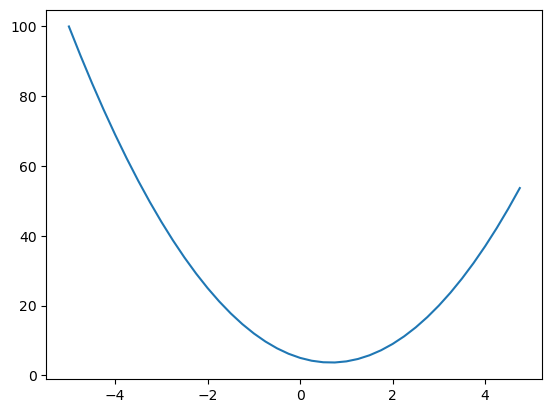

In [48]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [468]:
class Value: 
    def __init__(self, data, _children=(), _op='', label=''): 
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self): 
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out
        
    def __radd__(self, other): # other + self
        return self + other

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += out.grad * other.data
            other.grad += out.grad * self.data
        out._backward = _backward
        return out
        
    def __rmul__(self, other): 
        return self * other
        
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        def _backward(): 
            self.grad += (1 - t**2) * out.grad

        out._backward = _backward
        return out
    def exp(self): 
        x = self.data
        out = Value(math.exp(x), (self, ), "exp")
        def _backward(): 
            self.grad = out.data * out.grad;
        out._backward = _backward
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward
        return out

    def __sub__(self, other):
        return self + (other * -1)

    def __neg__(self): 
        return self * -1
    
    def __truediv__(self, other): 
        return self * (other ** -1)
        
    def backward(self): 
        topo = []
        visited = set() 
        def build_topo(v): 
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()
        

In [452]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

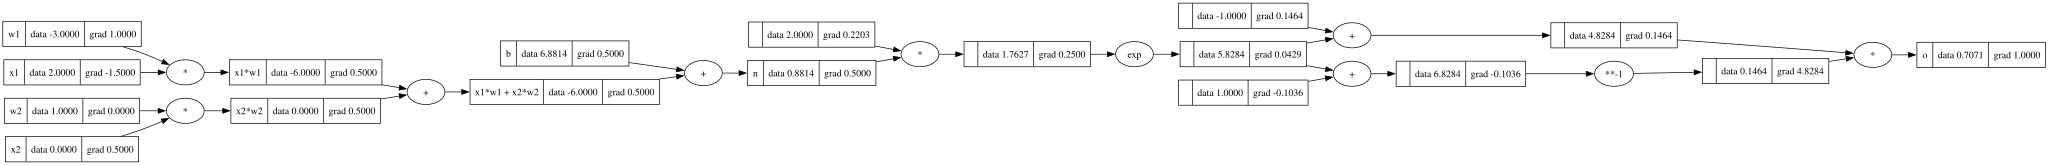

In [470]:


# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
# ----
e = (2*n).exp()
o = (e - 1) / (e + 1)
# ----
o.label = 'o'
o.backward()
draw_dot(o)



In [471]:
# let's using pytorch instead

In [472]:
import torch 

In [474]:
x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())


0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [641]:
class Neuron: 
    def __init__(self, nin): 
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))
    def __call__(self, x):
        act = sum((xi*wi for xi, wi in zip(self.w, x)), self.b)
        out = act.tanh() 
        return out
    def parameters(self):
        return self.w + [self.b]
class Layer: 
    def __init__(self, nin, nout): 
        self.neurons = [Neuron(nin) for _ in range(nout)] 
    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
class MLP: 
    def __init__(self, nin, nouts):
        sz = [nin] + nouts 
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x) 
        return x 
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
    

In [643]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=-0.5079990406790644)

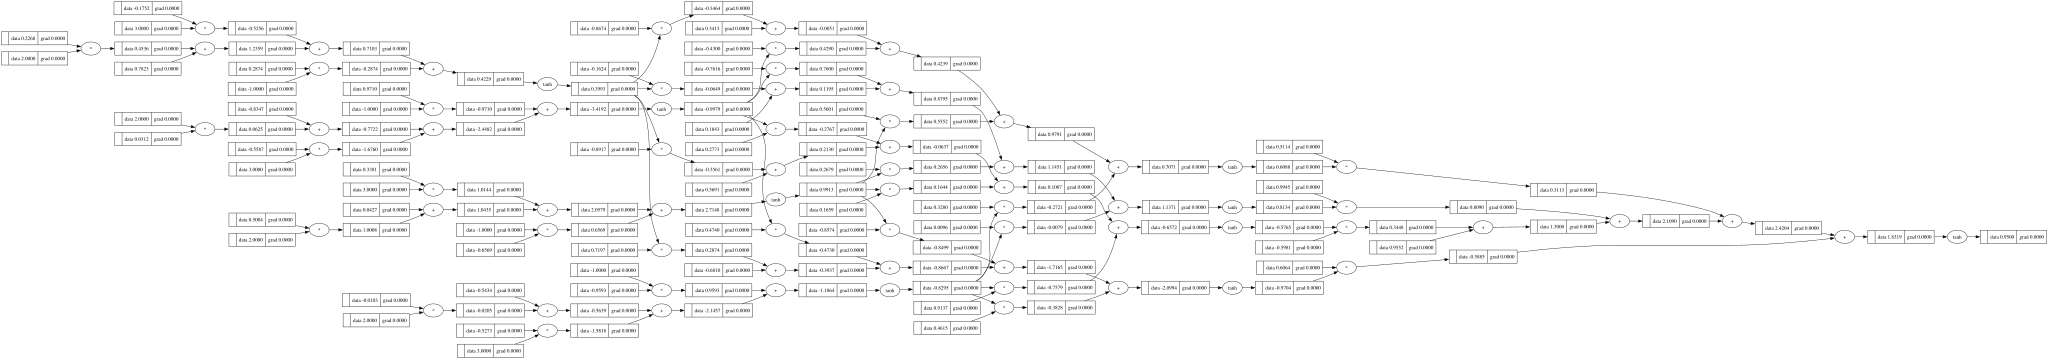

In [616]:
draw_dot(n(x))

In [716]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets


In [717]:
ypred = [n(x) for x in xs]
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

In [718]:
for p in n.parameters():
    p.grad = 0.0 
loss.backward()

In [719]:
for p in n.parameters():
    p.data += -0.1 * p.grad
print(loss.data)

0.026473163592228538


In [720]:
ypred

[Value(data=0.9443173014393714),
 Value(data=-0.9016736770717305),
 Value(data=-0.9592951140770516),
 Value(data=0.8902382254396362)]

In [723]:
for k in range(20):
  
  # forward pass
  ypred = [n(x) for x in xs]
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
  
  # backward pass
  for p in n.parameters():
    p.grad = 0.0
  loss.backward()
  
  # update
  for p in n.parameters():
    p.data += -0.1 * p.grad
  
  print(k, loss.data)
  


0 0.006884099114339711
1 0.006643409321316383
2 0.00641870343458521
3 0.0062084538714177046
4 0.006011320536762062
5 0.005826123049791089
6 0.005651817746396068
7 0.0054874785293134816
8 0.005332280837628265
9 0.005185488160345246
10 0.005046440636543734
11 0.004914545376048657
12 0.004789268205967433
13 0.0046701266045911
14 0.004556683628577285
15 0.004448542674675876
16 0.004345342945537301
17 0.004246755511889765
18 0.004152479881760337
19 0.004062241002352647


In [724]:
ypred

[Value(data=0.9771066453398317),
 Value(data=-0.9646852706435272),
 Value(data=-0.9792877600681736),
 Value(data=0.956849005547474)]